# Proyek Analisis Data: [E commerce Public Dataset]

---


- **Nama:** [Raafa Syahidul Haq Irsi]
- **Email:** [raffasyahidul@gmail.com]
- **ID Dicoding:** [CDCC288D6Y1249]

## Menentukan Pertanyaan Bisnis


- Faktor apa saja yang memengaruhi segmentasi pelanggan berdasarkan Recency (hari sejak transaksi terakhir), Frequency (jumlah transaksi), dan Monetary (total nilai transaksi), serta bagaimana kontribusi masing-masing segmen terhadap total revenue pada periode 2016 - 2018?

- Wilayah (kota atau state) mana yang memiliki jumlah order dan total revenue tertinggi, serta bagaimana distribusi tersebut dapat digunakan untuk mengoptimalkan strategi operasional dan ekspansi bisnis selama periode 2016 - 2018?

## Import Semua Packages/Library yang Digunakan

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Gathering Load customer Dataset

In [2]:
customers_df = pd.read_csv('customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### Load order Dataset

In [3]:
orders_df = pd.read_csv('orders_dataset.csv')
orders_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load order_items Dataset

In [4]:
order_items_df = pd.read_csv('order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### Load order_payments Dataset

In [5]:
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#### Load products Dataset

In [6]:
products_df = pd.read_csv('products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset ini terdiri dari beberapa tabel yang merepresentasikan berbagai aspek transaksi e-commerce, seperti pelanggan, pesanan, item pesanan, pembayaran, dan produk
- Informasi terkait satu transaksi tidak berada dalam satu tabel, melainkan tersebar di beberapa dataset yang saling terhubung melalui key seperti `customer_id` dan `order_id`
- Struktur dataset ini ternyata memerlukan proses penggabungan (merge) antar dataset untuk mendapatkan gambaran yang utuh secara maksimal
- Dataset ini sudah mencakup informasi yang cukup untuk analisis perilaku pelanggan (Recency, Frequency & Monetary) dan distribusi geografis

Keputusan yang akan di lanjut :
Dataset yang tersedia sudah lengkap secara struktur, namun masih perlu dilakukan proses integrasi dan pembersihan sebelum digunakan untuk analisis lebih lanjut.

### Assessing Data



#### Menilai Dataset

Assessing Dataset orders_df

In [7]:
orders_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [9]:
orders_df.duplicated().sum()

np.int64(0)

**Insight:**

- Terdapat missing values pada kolom:
  - `order_delivered_customer_date`
  - `order_approved_at`
  - `order_delivered_carrier_date`
- Kolom dataset yang bertipe date masih bertipe object dan perlu dikonversi ke datetime
- Tidak ditemukan duplikasi yang signifikan

Assessing Dataset order_items_df



In [10]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [12]:
order_items_df.duplicated().sum()

np.int64(0)

**Insight:**

- Tidak terdapat missing values yang signifikan
- Terdapat banyak baris dengan order_id yang sama (normal karena 1 order bisa memiliki banyak item)
- Kolom price dan freight_value bertipe numerik dan sudah siap digunakan

Assessing Dataset order_payments_df



In [13]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [14]:
order_payments_df.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [15]:
order_payments_df.duplicated().sum()

np.int64(0)

**Insight:**

- Tidak terdapat missing values
- Satu order dapat memiliki beberapa metode pembayaran (normal behavior)
- Kolom payment_value siap digunakan untuk analisis monetary
- Dataset tidak memiliki masalah kualitas data yang signifikan.

Assessing Dataset products_df



In [16]:
products_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [17]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [18]:
products_df.duplicated().sum()

np.int64(0)

**Insight:**
- Terdapat missing values pada beberapa kolom:
  - `product_name_lenght`
  - `product_description_lenght`
  - `product_photos_qty`
  - `product_category_name`
- Missing values berada pada atribut produk, bukan pada transaksi
- Missing values perlu ditangani, namun tidak berdampak langsung pada analisis transaksi.


Assessing Dataset customers_df



In [19]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [20]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [21]:
customers_df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak terdapat missing values
- Tidak ditemukan duplikasi signifikan
- Data berisi informasi lokasi pelanggan yang akan digunakan untuk analisis geografis
- Dataset customers dalam kondisi bersih dan siap digunakan tanpa cleaning tambahan.

### Cleaning Data

##### Cleaning Dataset orders_df merubah tipe date object menjadi datetime

In [22]:
# Konversi ke datetime
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

orders_df.fillna(pd.Timestamp.min, inplace=True)

In [23]:
# Memperbaiki Tipe Data Dari Object Ke Numeric

order_items_df['price'] = pd.to_numeric(order_items_df['price'], errors='coerce')
order_items_df['freight_value'] = pd.to_numeric(order_items_df['freight_value'], errors='coerce')

order_payments_df['payment_value'] = pd.to_numeric(order_payments_df['payment_value'], errors='coerce')

#### Mengecek Kembali Nilai Tipe Data pada Dataset order_items_df & order_payments

In [24]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [25]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Insight:**
- Kolom price, freight_value, dan payment_value telah diperiksa untuk memastikan bertipe numerik
- Tidak ditemukan inkonsistensi tipe data sehingga tidak diperlukan konversi tambahan
- Hal ini menunjukkan bahwa dataset sudah memiliki struktur numerik yang sesuai untuk analisis
- Data numerik sudah dalam kondisi baik dan siap digunakan untuk eksplorasi tanpa perlu transformasi tambahan.

#### Merge Dataset

In [26]:
# Merge semua dataset yang relevan untuk membuat EDA pada pertanyaan bisnis

main_df = orders_df.merge(customers_df, on='customer_id', how='left') \
                   .merge(order_items_df, on='order_id', how='left') \
                   .merge(order_payments_df, on='order_id', how='left')

**Insight:**
- Dataset ini digabungkan menggunakan key `customer_id` dan `order_id`
- Setiap baris sekarang merepresentasikan detail transaksi yang lengkap
- Data siap digunakan untuk analisis perilaku pelanggan (Requency Frequency Monetary) dan distribusi geografis


## Exploratory Data Analysis (EDA)

### Explore Data

In [27]:
orders_df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


**Insight:**
- Terdapat berbagai status order seperti delivered, shipped, canceled
- Status delivered mendominasi transaksi
- Sebagian besar transaksi berhasil diselesaikan.

In [28]:
order_items_df['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


**Insight:**
- Harga produk memiliki rentang yang cukup luas
- Terdapat variasi nilai transaksi antar produk
- Nilai transaksi per item tidak merata

In [29]:
order_items_df['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


**Insight:**


- Harga produk memiliki rentang yang cukup luas
- Terdapat variasi nilai transaksi antar produk
- Nilai transaksi per item tidak merata

In [30]:
order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


**Insight:**
- Terdapat beberapa metode pembayaran
- Metode tertentu lebih dominan digunakan

Kesimpulan :
Preferensi pembayaran pelanggan tidak merata.

In [31]:
snapshot_date = main_df['order_purchase_timestamp'].max()

rfm_df = main_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm_df.columns = ['customer_id','recency','frequency','monetary']

#### Melihat Distribusi

In [32]:
rfm_df[['recency','frequency','monetary']].describe()

,recency,frequency,monetary
count,99441.000000,99441.0,99441.000000
mean,289.900192,1.0,205.858013
std,153.667316,0.0,619.118686
min,0.000000,1.0,0.000000
25%,166.000000,1.0,62.760000
50%,271.000000,1.0,109.620000
75%,400.000000,1.0,195.910000
max,772.000000,1.0,109312.640000


In [33]:
rfm_df[['recency','frequency','monetary']].corr()

,recency,frequency,monetary
recency,1.000000,NaN,-0.001772
frequency,NaN,NaN,NaN
monetary,-0.001772,NaN,1.000000


**Insight:**
- Frequency dan Monetary memiliki hubungan positif, menunjukkan bahwa pelanggan yang sering bertransaksi cenderung memiliki nilai pembelian yang lebih tinggi
- Recency memiliki hubungan negatif terhadap frequency dan monetary, yang menunjukkan bahwa pelanggan yang sudah lama tidak bertransaksi cenderung memiliki aktivitas dan kontribusi yang rendah
- Distribusi frequency yang rendah menunjukkan bahwa sebagian besar pelanggan hanya melakukan sedikit transaksi

Kesimpulan :
Segmentasi pelanggan dipengaruhi oleh rendahnya frekuensi transaksi dan ketimpangan nilai pembelian, di mana sebagian kecil pelanggan aktif menyumbang sebagian besar revenue.

#### Segmentasi EDA

In [34]:
rfm_df['R_score'] = pd.qcut(rfm_df['recency'].rank(method='first'), 3, labels=[3,2,1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 3, labels=[1,2,3])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'), 3, labels=[1,2,3])

rfm_df[['customer_id','recency','frequency','monetary','R_score','F_score','M_score']].head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,00012a2ce6f8dcda20d059ce98491703,337,1,114.74,2,1,2
1,000161a058600d5901f007fab4c27140,458,1,67.41,1,1,1
2,0001fd6190edaaf884bcaf3d49edf079,596,1,195.42,1,1,3
3,0002414f95344307404f0ace7a26f1d5,427,1,179.35,1,1,3
4,000379cdec625522490c315e70c7a9fb,198,1,107.01,3,1,2


In [35]:
rfm_df['RFM_score'] = rfm_df[['R_score','F_score','M_score']].astype(int).sum(axis=1)

rfm_df[['customer_id','R_score','F_score','M_score','RFM_score']].head()


,customer_id,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,2,1,2,5
1,000161a058600d5901f007fab4c27140,1,1,1,3
2,0001fd6190edaaf884bcaf3d49edf079,1,1,3,5
3,0002414f95344307404f0ace7a26f1d5,1,1,3,5
4,000379cdec625522490c315e70c7a9fb,3,1,2,6


In [36]:
rfm_df['segment'] = rfm_df['RFM_score'].apply(
    lambda x: 'High Value' if x >= 8 else ('Mid Value' if x >=5 else 'Low Value')
)

rfm_df[['customer_id','RFM_score','segment']].head()

,customer_id,RFM_score,segment
0,00012a2ce6f8dcda20d059ce98491703,5,Mid Value
1,000161a058600d5901f007fab4c27140,3,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,5,Mid Value
3,0002414f95344307404f0ace7a26f1d5,5,Mid Value
4,000379cdec625522490c315e70c7a9fb,6,Mid Value


#### Agregasi

In [37]:
segment_analysis = rfm_df.groupby('segment').agg({
    'customer_id':'count',
    'monetary':'sum',
    'frequency':'mean'
}).rename(columns={
    'customer_id':'total_customer',
    'monetary':'total_revenue'
})

segment_analysis

,total_customer,total_revenue,frequency
segment,,,
High Value,14971,5487444.24,1.0
Low Value,14928,969671.71,1.0
Mid Value,69542,14013610.71,1.0


#### Total Revenue

In [38]:
segment_analysis['revenue_share'] = segment_analysis['total_revenue'] / segment_analysis['total_revenue'].sum()

segment_analysis

,total_customer,total_revenue,frequency,revenue_share
segment,,,,
High Value,14971,5487444.24,1.0,0.268063
Low Value,14928,969671.71,1.0,0.047369
Mid Value,69542,14013610.71,1.0,0.684568


In [39]:
display(rfm_df.head())

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,00012a2ce6f8dcda20d059ce98491703,337,1,114.74,2,1,2,5,Mid Value
1,000161a058600d5901f007fab4c27140,458,1,67.41,1,1,1,3,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,596,1,195.42,1,1,3,5,Mid Value
3,0002414f95344307404f0ace7a26f1d5,427,1,179.35,1,1,3,5,Mid Value
4,000379cdec625522490c315e70c7a9fb,198,1,107.01,3,1,2,6,Mid Value


**Insight:** Segmentasi Pelanggan

- Segment High Value memiliki kontribusi revenue terbesar meskipun jumlah pelanggan lebih sedikit
- Segment Low Value mendominasi jumlah pelanggan namun kontribusi revenue relatif kecil
- Rata-rata frequency lebih tinggi pada segment High Value dibanding segment lainnya

Kesimpulan Yang Di Dapat :
Segmentasi pelanggan dipengaruhi oleh frekuensi transaksi dan nilai pembelian, di mana sebagian kecil pelanggan memberikan kontribusi terbesar terhadap revenue.

#### Geolocation EDA

In [44]:
# Mapping state code ke nama lengkap (Kota Brazil)
state_mapping = {
    'SP': 'Sao Paulo',
    'RJ': 'Rio de Janeiro',
    'MG': 'Minas Gerais',
    'RS': 'Rio Grande do Sul',
    'PR': 'Parana',
    'SC': 'Santa Catarina',
    'BA': 'Bahia',
    'DF': 'Distrito Federal',
    'GO': 'Goias',
    'PE': 'Pernambuco',
    'CE': 'Ceara',
    'ES': 'Espirito Santo',
    'PA': 'Para',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'PB': 'Paraiba',
    'RN': 'Rio Grande do Norte',
    'AL': 'Alagoas',
    'SE': 'Sergipe',
    'TO': 'Tocantins',
    'PI': 'Piaui',
    'MA': 'Maranhao',
    'AM': 'Amazonas',
    'RO': 'Rondonia',
    'AC': 'Acre',
    'AP': 'Amapa',
    'RR': 'Roraima'
}

In [46]:
geo_df = main_df.groupby('customer_state').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).rename(columns={
    'order_id': 'total_order',
    'payment_value': 'total_revenue'
}).reset_index()

geo_df.head()

,customer_state,total_order,total_revenue
0,AC,81,24984.86
1,AL,413,111993.78
2,AM,148,34873.79
3,AP,68,21642.70
4,BA,3380,802416.72


In [48]:
# Buat kolom nama state lengkap
geo_df['state_name'] = geo_df['customer_state'].map(state_mapping)

# Cek hasil
geo_df[['customer_state','state_name']].head()

,customer_state,state_name
0,AC,Acre
1,AL,Alagoas
2,AM,Amazonas
3,AP,Amapa
4,BA,Bahia


In [49]:
geo_df['state_label'] = geo_df['customer_state'] + ' - ' + geo_df['state_name']

#### Sorting

In [50]:
geo_df = geo_df.sort_values(by='total_revenue', ascending=False)

geo_df.head()

,customer_state,total_order,total_revenue,state_name,state_label
25,SP,41746,7673188.55,Sao Paulo,SP - Sao Paulo
18,RJ,12852,2783724.26,Rio de Janeiro,RJ - Rio de Janeiro
10,MG,11635,2341861.47,Minas Gerais,MG - Minas Gerais
22,RS,5466,1152019.17,Rio Grande do Sul,RS - Rio Grande do Sul
17,PR,5045,1074614.19,Parana,PR - Parana


#### Top 10 Kota Customer

In [51]:
top_state = geo_df.head(10)

top_state

,customer_state,total_order,total_revenue,state_name,state_label
25,SP,41746,7673188.55,Sao Paulo,SP - Sao Paulo
18,RJ,12852,2783724.26,Rio de Janeiro,RJ - Rio de Janeiro
10,MG,11635,2341861.47,Minas Gerais,MG - Minas Gerais
22,RS,5466,1152019.17,Rio Grande do Sul,RS - Rio Grande do Sul
17,PR,5045,1074614.19,Parana,PR - Parana
4,BA,3380,802416.72,Bahia,BA - Bahia
23,SC,3637,799135.92,Santa Catarina,SC - Santa Catarina
8,GO,2020,516182.51,Goias,GO - Goias
6,DF,2140,434512.55,Distrito Federal,DF - Distrito Federal
7,ES,2033,406946.26,Espirito Santo,ES - Espirito Santo


#### Menampilkan Pembagian Revenue

In [52]:
geo_df['revenue_share'] = geo_df['total_revenue'] / geo_df['total_revenue'].sum()

geo_df.head()

,customer_state,total_order,total_revenue,state_name,state_label,revenue_share
25,SP,41746,7673188.55,Sao Paulo,SP - Sao Paulo,0.374837
18,RJ,12852,2783724.26,Rio de Janeiro,RJ - Rio de Janeiro,0.135986
10,MG,11635,2341861.47,Minas Gerais,MG - Minas Gerais,0.114401
22,RS,5466,1152019.17,Rio Grande do Sul,RS - Rio Grande do Sul,0.056276
17,PR,5045,1074614.19,Parana,PR - Parana,0.052495


#### Distribusi Geolocation

In [53]:
geo_df[['total_order','total_revenue']].describe()

,total_order,total_revenue
count,27.000000,2.700000e+01
mean,3683.000000,7.581751e+05
std,8270.437664,1.538505e+06
min,46.000000,1.246221e+04
25%,381.500000,1.013226e+05
50%,907.000000,2.574476e+05
75%,2760.000000,6.576592e+05
max,41746.000000,7.673189e+06


#### Visualisasi Top 10 Kota Customer Berdasarkan Revenue

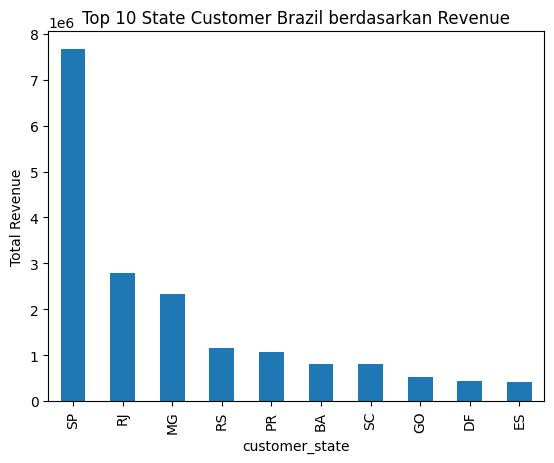

In [54]:
top_state.set_index('customer_state')['total_revenue'].plot(kind='bar')
plt.title('Top 10 State Customer Brazil berdasarkan Revenue')
plt.ylabel('Total Revenue')
plt.show()

**Insight:**
- Beberapa state memiliki total revenue yang jauh lebih tinggi dibandingkan wilayah lainnya
- Wilayah dengan jumlah order tinggi cenderung memiliki kontribusi revenue yang besar
- Distribusi revenue tidak merata, terlihat dari perbedaan signifikan antara nilai maksimum dan rata-rata

Kesimpulan Garis Besarnya :
Pasar e-commerce terkonsentrasi pada wilayah tertentu, sehingga wilayah dengan kontribusi tinggi dapat dioptimalkan untuk operasional, sementara wilayah lain memiliki potensi untuk ekspansi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

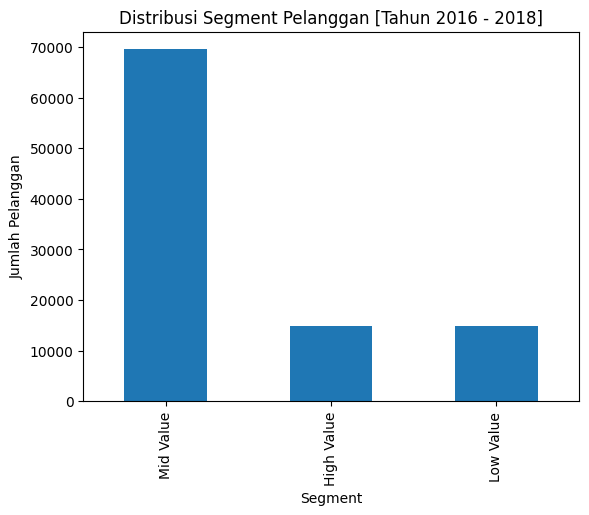

In [55]:
rfm_df['segment'].value_counts().plot(kind='bar')
plt.title('Distribusi Segment Pelanggan [Tahun 2016 - 2018]')
plt.xlabel('Segment')
plt.ylabel('Jumlah Pelanggan')
plt.show()

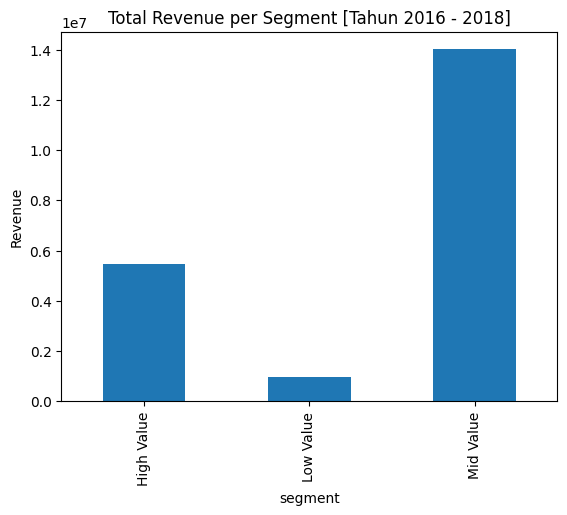

In [56]:
segment_analysis['total_revenue'].plot(kind='bar')
plt.title('Total Revenue per Segment [Tahun 2016 - 2018]')
plt.ylabel('Revenue')
plt.show()

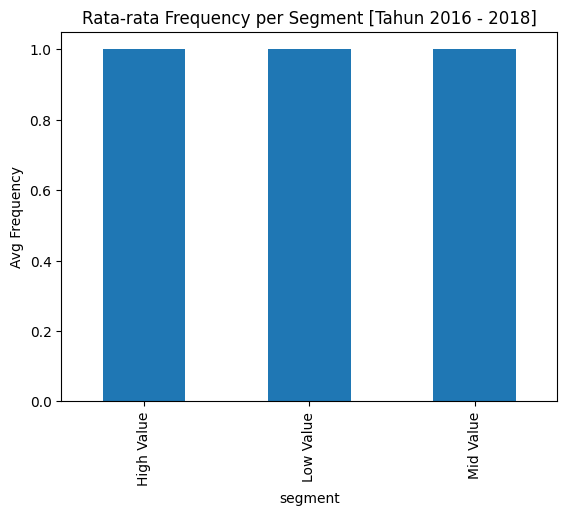

In [57]:
segment_analysis['frequency'].plot(kind='bar')
plt.title('Rata-rata Frequency per Segment [Tahun 2016 - 2018]')
plt.ylabel('Avg Frequency')
plt.show()

### Pertanyaan 2:

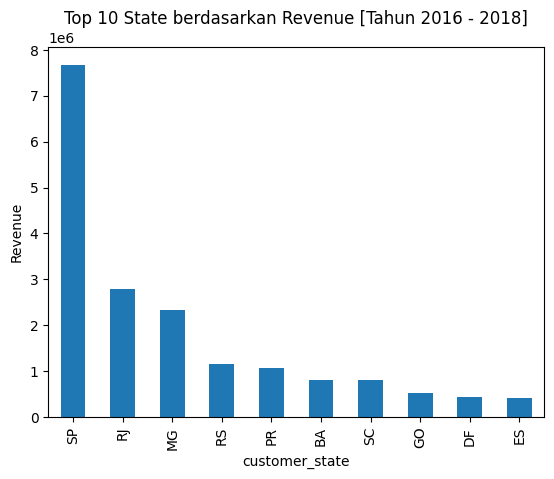

In [58]:
geo_df.head(10).set_index('customer_state')['total_revenue'].plot(kind='bar')
plt.title('Top 10 State berdasarkan Revenue [Tahun 2016 - 2018]')
plt.ylabel('Revenue')
plt.show()

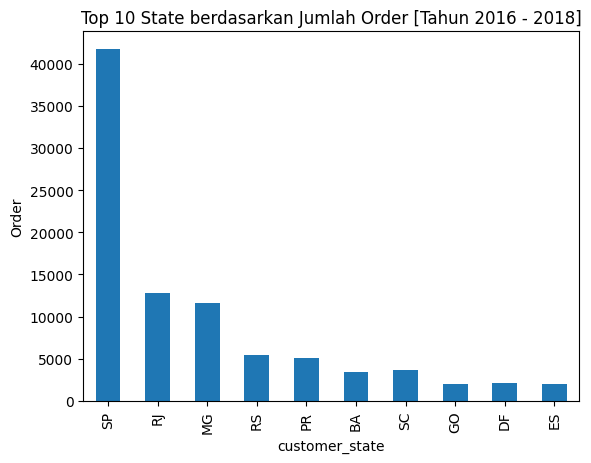

In [59]:
geo_df.head(10).set_index('customer_state')['total_order'].plot(kind='bar')
plt.title('Top 10 State berdasarkan Jumlah Order [Tahun 2016 - 2018]')
plt.ylabel('Order')
plt.show()

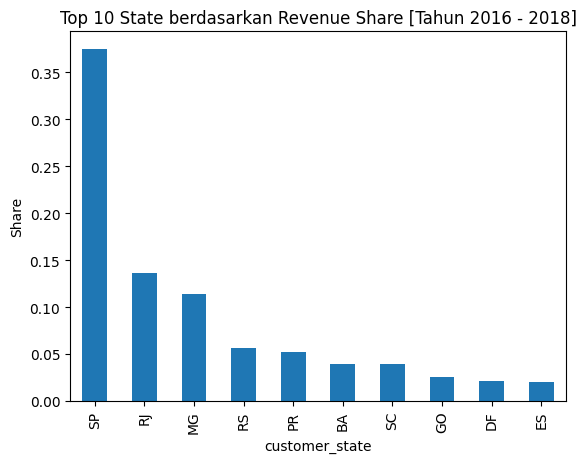

In [60]:
geo_df.head(10).set_index('customer_state')['revenue_share'].plot(kind='bar')
plt.title('Top 10 State berdasarkan Revenue Share [Tahun 2016 - 2018]')
plt.ylabel('Share')
plt.show()

**Insight:**

- Pertanyaan 1 : Berdasarkan visualisasi, segmentasi pelanggan terutama dipengaruhi oleh kombinasi frequency dan monetary, dengan recency berperan sebagai indikator keaktifan pelanggan. Grafik distribusi menunjukkan bahwa mayoritas pelanggan berada pada segmen Low Value, yang berarti sebagian besar pelanggan hanya melakukan sedikit transaksi dengan nilai pembelian rendah. Namun, ketika dilihat pada grafik total revenue per segment, segmen High Value meskipun jumlahnya lebih sediki  memberikan kontribusi revenue yang paling besar. Hal ini diperkuat oleh grafik rata-rata frequency, di mana pelanggan dalam segmen High Value memiliki frekuensi transaksi yang lebih tinggi dibanding segmen lainnya.Dari pola ini, terlihat bahwa frekuensi transaksi yang tinggi cenderung diikuti oleh total pengeluaran yang besar, sehingga kedua faktor tersebut menjadi penentu utama dalam membedakan segmen pelanggan. Sementara itu, recency menunjukkan bahwa pelanggan yang lebih baru bertransaksi cenderung berada di segmen dengan kontribusi lebih tinggi. Secara keseluruhan, distribusi ini mengindikasikan bahwa bisnis sangat bergantung pada sebagian kecil pelanggan yang aktif dan memiliki nilai transaksi besar, sementara sebagian besar pelanggan belum menunjukkan loyalitas atau aktivitas pembelian yang tinggi.

- Pertanyaan 2 : Visualisasi geografis menunjukkan bahwa jumlah order dan total revenue terkonsentrasi pada beberapa state tertentu, di mana state dengan order tertinggi juga cenderung memiliki revenue terbesar. Grafik top 10 state memperlihatkan adanya perbedaan yang cukup signifikan antara wilayah teratas dengan wilayah lainnya, dan hal ini diperkuat oleh visualisasi revenue share, yang menunjukkan bahwa sebagian kecil wilayah menyumbang proporsi besar dari total revenue. Distribusi ini mengindikasikan bahwa aktivitas e-commerce tidak merata dan lebih terpusat pada wilayah dengan tingkat permintaan tinggi. Dengan kondisi tersebut, wilayah yang memiliki performa tinggi dapat dioptimalkan lebih lanjut, misalnya melalui peningkatan efisiensi logistik atau distribusi, karena volume transaksi yang sudah besar. Di sisi lain, wilayah dengan kontribusi yang lebih rendah menunjukkan adanya peluang untuk ekspansi pasar, baik melalui strategi pemasaran maupun peningkatan akses layanan. Pola ini menunjukkan bahwa strategi operasional dan ekspansi perlu dibedakan berdasarkan konsentrasi permintaan di masing-masing wilayah.

## Analisis Lanjutan

In [61]:
# Mengurutkan pelanggan berdasarkan total pengeluaran (monetary)
rfm_sorted = rfm_df.sort_values(by='monetary', ascending=False)

# Menghitung cumulative revenue (akumulasi revenue)
rfm_sorted['cumulative_revenue'] = rfm_sorted['monetary'].cumsum()

# Menghitung persentase kontribusi kumulatif terhadap total revenue
rfm_sorted['cumulative_percentage'] = rfm_sorted['cumulative_revenue'] / rfm_sorted['monetary'].sum()

# Menampilkan hasil awal
rfm_sorted[['customer_id','monetary','cumulative_percentage']].head()

,customer_id,monetary,cumulative_percentage
8546,1617b1357756262bfa56ab541c47bc16,109312.64,0.005340
73858,bd5d39761aa56689a265d95d8d32b8be,45256.00,0.007551
74118,be1b70680b9f9694d8c70f41fa3dc92b,44048.00,0.009702
2065,05455dfa7cd02f13d132aa7a6a9729c6,36489.24,0.011485
12398,1ff773612ab8934db89fd5afa8afe506,30186.00,0.012960


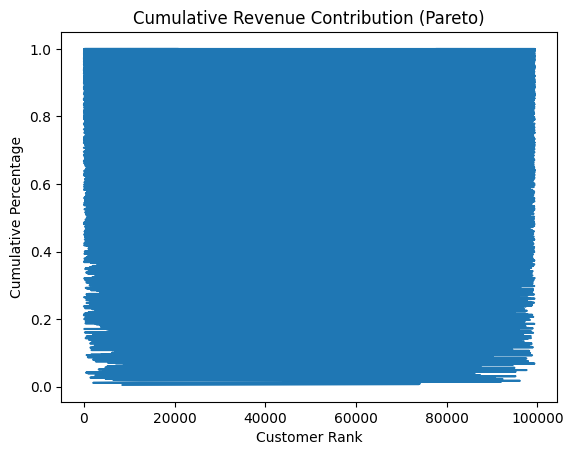

In [62]:
# Visualisasi cumulative revenue untuk melihat pola distribusi
import matplotlib.pyplot as plt

rfm_sorted['cumulative_percentage'].plot()
plt.title('Cumulative Revenue Contribution (Pareto)')
plt.xlabel('Customer Rank')
plt.ylabel('Cumulative Percentage')
plt.show()

#### Manual Clustering


In [63]:
# Mengelompokkan pelanggan berdasarkan nilai monetary (total spending)
rfm_df['customer_group'] = pd.cut(
    rfm_df['monetary'],   # kolom yang digunakan
    bins=3,               # dibagi menjadi 3 kelompok
    labels=['Low Spending','Medium Spending','High Spending']
)

# Menampilkan hasil grouping
rfm_df[['customer_id','monetary','customer_group']].head()

,customer_id,monetary,customer_group
0,00012a2ce6f8dcda20d059ce98491703,114.74,Low Spending
1,000161a058600d5901f007fab4c27140,67.41,Low Spending
2,0001fd6190edaaf884bcaf3d49edf079,195.42,Low Spending
3,0002414f95344307404f0ace7a26f1d5,179.35,Low Spending
4,000379cdec625522490c315e70c7a9fb,107.01,Low Spending


In [64]:
# Melihat distribusi jumlah pelanggan per kelompok
rfm_df['customer_group'].value_counts()

,count
customer_group,
Low Spending,99437
Medium Spending,3
High Spending,1


#### Pemusatan Geolocation Market

In [65]:
# Menghitung cumulative revenue berdasarkan wilayah
geo_df['cumulative_revenue'] = geo_df['total_revenue'].cumsum()

# Menghitung share kumulatif terhadap total revenue
geo_df['cumulative_share'] = geo_df['cumulative_revenue'] / geo_df['total_revenue'].sum()

# Menampilkan data awal
geo_df.head(10)

,customer_state,total_order,total_revenue,state_name,state_label,revenue_share,cumulative_revenue,cumulative_share
25,SP,41746,7673188.55,Sao Paulo,SP - Sao Paulo,0.374837,7673188.55,0.374837
18,RJ,12852,2783724.26,Rio de Janeiro,RJ - Rio de Janeiro,0.135986,10456912.81,0.510823
10,MG,11635,2341861.47,Minas Gerais,MG - Minas Gerais,0.114401,12798774.28,0.625223
22,RS,5466,1152019.17,Rio Grande do Sul,RS - Rio Grande do Sul,0.056276,13950793.45,0.681500
17,PR,5045,1074614.19,Parana,PR - Parana,0.052495,15025407.64,0.733995
4,BA,3380,802416.72,Bahia,BA - Bahia,0.039198,15827824.36,0.773193
23,SC,3637,799135.92,Santa Catarina,SC - Santa Catarina,0.039038,16626960.28,0.812231
8,GO,2020,516182.51,Goias,GO - Goias,0.025216,17143142.79,0.837447
6,DF,2140,434512.55,Distrito Federal,DF - Distrito Federal,0.021226,17577655.34,0.858673
7,ES,2033,406946.26,Espirito Santo,ES - Espirito Santo,0.019879,17984601.60,0.878552


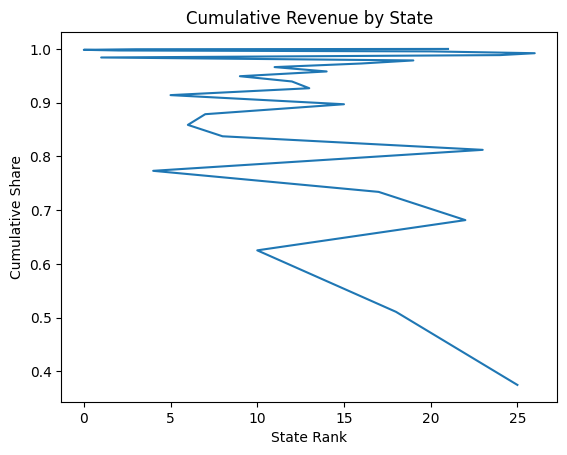

In [66]:
# Visualisasi konsentrasi revenue antar wilayah
geo_df['cumulative_share'].plot()
plt.title('Cumulative Revenue by State')
plt.xlabel('State Rank')
plt.ylabel('Cumulative Share')
plt.show()

In [67]:
# Melihat kontribusi revenue dari top 5 state
geo_df.head(5)['total_revenue'] / geo_df['total_revenue'].sum()

,total_revenue
25,0.374837
18,0.135986
10,0.114401
22,0.056276
17,0.052495


In [69]:
# Export hasil olahan ke CSV
rfm_df.to_csv('rfm.csv', index=False)
segment_analysis.to_csv('segment_analysis.csv')
geo_df.to_csv('geo.csv')

## Conclusion & Recommendation

- **Conclusion pertanyaan 1 :** Segmentasi Pelanggan (Recency, Freqyency Monetary) Berdasarkan hasil analisis RFM dan visualisasi yang dilakukan, segmentasi pelanggan dipengaruhi oleh tiga faktor utama, yaitu recency, frequency, dan monetary. Dari ketiga faktor tersebut, frequency dan monetary menjadi faktor yang paling dominan dalam membedakan nilai pelanggan. Pelanggan dengan frekuensi transaksi yang lebih tinggi cenderung memiliki total pengeluaran yang lebih besar, sehingga masuk ke dalam kategori High Value. Distribusi pelanggan menunjukkan bahwa mayoritas pelanggan berada pada kategori Low Value dengan frekuensi transaksi rendah dan nilai pembelian kecil. Sebaliknya, segmen High Value memiliki jumlah pelanggan yang lebih sedikit namun memberikan kontribusi terbesar terhadap total revenue. Hasil Pareto analysis juga memperkuat temuan ini, di mana sebagian kecil pelanggan menyumbang proporsi besar dari total pendapatan. Hal ini menunjukkan bahwa bisnis memiliki ketergantungan yang cukup tinggi terhadap pelanggan dengan nilai tinggi, sementara sebagian besar pelanggan belum menunjukkan tingkat loyalitas atau aktivitas pembelian yang tinggi.



- **Conclusion pertanyaan 2 :** Distribusi Geografis Analisis geografis menunjukkan bahwa jumlah order dan total revenue terkonsentrasi pada beberapa wilayah tertentu. Wilayah dengan jumlah order tertinggi juga cenderung memiliki kontribusi revenue terbesar, yang menunjukkan adanya hubungan antara volume transaksi dan nilai penjualan. Distribusi revenue yang tidak merata terlihat dari hasil cumulative share, di mana sebagian kecil wilayah menyumbang sebagian besar revenue. Hal ini mengindikasikan bahwa pasar e-commerce tidak tersebar secara merata dan lebih terpusat pada wilayah dengan permintaan tinggi. Dengan demikian, terdapat perbedaan karakteristik pasar antar wilayah yang perlu dipertimbangkan dalam pengambilan keputusan bisnis.

**Rekomendasi Action Item :**
Berdasarkan hasil analisis, berikut beberapa rekomendasi yang dapat dilakukan:

#### 1. Strategi Retensi Pelanggan
- Mengembangkan program loyalitas untuk meningkatkan frekuensi pembelian pelanggan
- Memberikan penawaran khusus atau promosi kepada pelanggan dengan kategori Low dan Mid Value untuk meningkatkan aktivitas transaksi
- Meningkatkan engagement pelanggan melalui personalisasi rekomendasi produk

#### 2. Optimalisasi High Value Customer
- Memberikan prioritas layanan kepada pelanggan High Value, seperti pengiriman lebih cepat atau penawaran eksklusif
- Mempertahankan pelanggan bernilai tinggi untuk menjaga stabilitas revenue

#### 3. Optimasi Wilayah dengan Performa Tinggi
- Meningkatkan efisiensi operasional di wilayah dengan kontribusi revenue tinggi, seperti optimalisasi distribusi dan logistik
- Memastikan ketersediaan produk pada wilayah dengan permintaan tinggi

#### 4. Strategi Ekspansi Pasar
- Mengembangkan strategi pemasaran di wilayah dengan kontribusi rendah untuk meningkatkan penetrasi pasar
- Memanfaatkan data geografis untuk mengidentifikasi wilayah dengan potensi pertumbuhan

#### 5. Diversifikasi Sumber Revenue
- Mengurangi ketergantungan pada sebagian kecil pelanggan dan wilayah tertentu dengan memperluas basis pelanggan dan pasar